In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Simulate some data
nobs = 100
np.random.seed(1234)
y = pd.DataFrame(
    np.random.normal(size=(nobs, 2)), columns=['y1', 'y2']
)
X_1 = pd.Series(np.random.normal(size=nobs), name='x1')
X_2 = pd.Series(np.random.normal(size=nobs), name='x2')
X = pd.concat([X_1, X_2], axis=1)

# Build the model with exogenous variables
mod = sm.tsa.DynamicFactor(
    endog=y, exog=X, k_factors=1, factor_order=1, error_order=1
)

# View available parameter names to know what to fix
print(mod.param_names)

print(mod.state_names)



['loading.f1.y1', 'loading.f1.y2', 'beta.x1.y1', 'beta.x2.y1', 'beta.x1.y2', 'beta.x2.y2', 'sigma2.y1', 'sigma2.y2', 'L1.f1.f1', 'L1.e(y1).e(y1)', 'L1.e(y2).e(y2)']
['f1', 'e(y1)', 'e(y2)']


In [2]:

res = mod.fit(disp=False)

print(res.summary())

                                   Statespace Model Results                                  
Dep. Variable:                          ['y1', 'y2']   No. Observations:                  100
Model:             DynamicFactor(factors=1, order=1)   Log Likelihood                -275.792
                                      + 2 regressors   AIC                            573.583
                                      + AR(1) errors   BIC                            602.240
Date:                               Thu, 14 Aug 2025   HQIC                           585.181
Time:                                       13:48:20                                         
Sample:                                            0                                         
                                               - 100                                         
Covariance Type:                                 opg                                         
Ljung-Box (L1) (Q):             0.01, 0.01   Jarque-Bera (JB

In [3]:
ssm = res.model.ssm

In [4]:
print("Z:\n", ssm['design'])
print("d:\n", ssm['obs_intercept'])
print("H:\n", ssm['obs_cov'])
print("T:\n", ssm['transition'])
print("c:\n", ssm['state_intercept'])
print("R:\n", ssm['selection'])
print("Q:\n", ssm['state_cov'])

Z:
 [[-0.20452866  1.          0.        ]
 [ 0.95613219  0.          1.        ]]
d:
 [[-0.02901487 -0.02670404  0.01032248 -0.21295536  0.09582011  0.06113231
  -0.10140232 -0.06105449 -0.14210127  0.11450068 -0.0612307   0.08755969
  -0.08510112 -0.23228266 -0.09380269 -0.03959632 -0.13720299  0.0503367
   0.04044094  0.05176901 -0.07639738 -0.21761618 -0.09492046 -0.07137404
   0.06175861  0.1694778  -0.15578984 -0.00907372 -0.14640439  0.0239046
  -0.025246   -0.0457828   0.00390072  0.05231156  0.09844961 -0.04180438
  -0.16969122 -0.18000683 -0.03879985 -0.08532984 -0.00695939 -0.08672532
  -0.11246558  0.08586357  0.19352823 -0.07144073  0.00241893 -0.06523033
   0.01763271  0.0737319  -0.08217934 -0.02953723  0.12694692  0.03518211
   0.12687181  0.08756044 -0.02272647 -0.23581493 -0.08867368  0.02627456
  -0.19609722 -0.11602388 -0.05300267 -0.03828583 -0.25547103 -0.20255764
   0.08576411 -0.0043174  -0.02574091  0.07707109  0.05652504  0.03381566
   0.15748979  0.02760425  

In [5]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader.data import DataReader
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
import arviz as az
import pytensor.tensor as pt
import pymc as pm
import pytensor


from pymc_extras.statespace.core.statespace import PyMCStateSpace
from pymc_extras.statespace.utils.constants import (
    ALL_STATE_AUX_DIM,
    ALL_STATE_DIM
)

from pymc_extras.statespace.models.DFM import BayesianDynamicFactor


In [6]:
# Create DFM Statespace Model
dfm_mod = BayesianDynamicFactor(
    k_factors=1,
    factor_order=1,
    k_endog=2,
    error_order=1,
    error_var=False,
    k_exog=2,
    error_cov_type="diagonal",
    measurement_error=False,
    verbose=True
)

                                     Model Requirements                                      
                                                                                             
  Variable          Shape       Constraints                                      Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (7,)                                                         ('state',)  
  P0                (7, 7)      Positive Semi-definite               ('state', 'state_aux')  
  factor_loadings   (2, 1)                                     ('observed_state', 'factor')  
  factor_ar         (1, 1)                                             ('factor', 'lag_ar')  
  error_ar          (2, 1)                               ('observed_state', 'error_lag_ar')  
  error_sigma       (2,)        Positive                                ('observed_state',)  
  beta              (4,)                                               ('exogenous_state',)  
                                                                                             
  exog_data         (None, 2)   pm.Data                         ('time', 'exogenous_state')  
                                                                                             
   These parameters should be assigned priors inside a PyMC model block before calling the   
                               build_statespace_graph method.                                

In [7]:
dfm_mod.param_names

['x0', 'P0', 'factor_loadings', 'factor_ar', 'error_ar', 'error_sigma', 'beta']

In [8]:
dfm_mod.param_dims.values()

dict_values([('state',), ('state', 'state_aux'), ('observed_state', 'factor'), ('factor', 'lag_ar'), ('observed_state', 'error_lag_ar'), ('observed_state',), ('exogenous_state',)])

In [9]:
dfm_mod.param_info

{'x0': {'shape': (7,), 'constraints': None, 'dims': ('state',)},
 'P0': {'shape': (7, 7),
  'constraints': 'Positive Semi-definite',
  'dims': ('state', 'state_aux')},
 'factor_loadings': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'factor')},
 'factor_ar': {'shape': (1, 1),
  'constraints': None,
  'dims': ('factor', 'lag_ar')},
 'error_ar': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'error_lag_ar')},
 'error_sigma': {'shape': (2,),
  'constraints': 'Positive',
  'dims': ('observed_state',)},
 'beta': {'shape': (4,), 'constraints': None, 'dims': ('exogenous_state',)}}

In [10]:
dfm_mod.data_info

{'exog_data': {'shape': (None, 2), 'dims': ('time', 'exogenous_state')}}

In [11]:
# Unpack dims and coords
x0_dims, P0_dims, factor_loadings_dims, factor_ar_dims, error_ar_dims, error_sigma_dims, beta_dims = dfm_mod.param_dims.values()
coords = dfm_mod.coords

In [12]:
print(X.shape)

(100, 2)


In [13]:

time_index = pd.date_range(start='2020-01-01', periods=len(X), freq='D')
X.index = time_index

print(X.shape)
print(X.shape)


(100, 2)
(100, 2)


In [14]:
print(X)

                  x1        x2
2020-01-01 -0.319561  0.527046
2020-01-02 -0.619993  0.711112
2020-01-03  0.156998 -0.217545
2020-01-04 -0.571455  2.637791
2020-01-05  1.057633 -1.742138
...              ...       ...
2020-04-05  1.343182  0.048264
2020-04-06 -0.050540  0.061988
2020-04-07 -0.364010 -1.027516
2020-04-08 -1.553342 -0.238335
2020-04-09 -0.319298  1.932178

[100 rows x 2 columns]


In [15]:
with pm.Model(coords=coords) as pymc_mod:
    exog_data = pm.Data("exog_data",X)

    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(7))
    P0 = pm.Deterministic("P0", pt.eye(7))
    factor_loadings = pm.Normal("factor_loadings", sigma=1, dims=factor_loadings_dims)
    factor_ar = pm.Normal("factor_ar", sigma=1, dims=factor_ar_dims)
    #factor_sigma = pm.Deterministic("factor_sigma", pt.constant([1.0], dtype=float))
    error_ar = pm.Normal("error_ar", sigma=1, dims=error_ar_dims)
    sigmas = pm.HalfNormal("error_sigma", dims=error_sigma_dims)
    beta = pm.Normal("beta", sigma=1, dims=beta_dims)
    # Build symbolic graph
    dfm_mod.build_statespace_graph(data=y, mode="JAX")


/Users/andrea/Desktop/gitProject/pymc-extras/pymc_extras/statespace/utils/data_tools.py:100: UserWarning: No time index found on the supplied data. A simple range index will be automatically generated.
  warnings.warn(NO_TIME_INDEX_WARNING)
/Users/andrea/Desktop/gitProject/pymc-extras/pymc_extras/statespace/utils/data_tools.py:74: UserWarning: No time index found on the supplied data. A simple range index will be automatically generated.
  warnings.warn(NO_TIME_INDEX_WARNING)


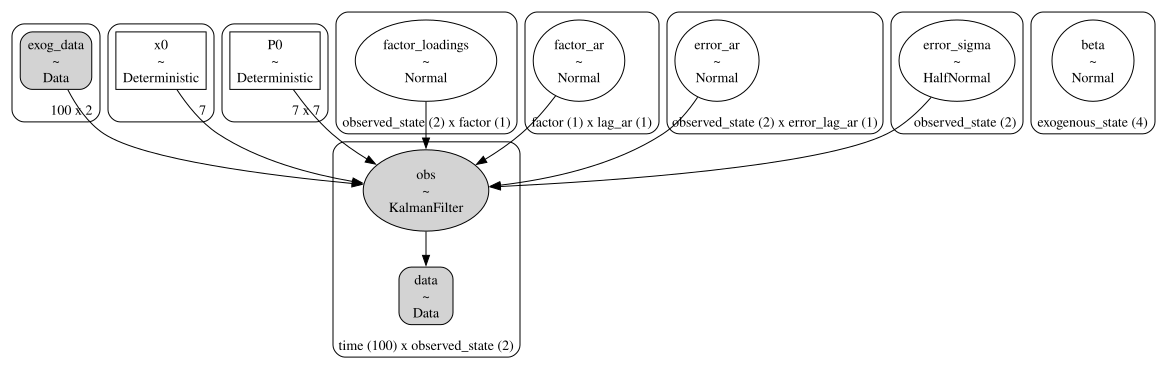

In [16]:
pymc_mod.to_graphviz()

In [17]:
matrix_names = [
    "initial_state",
    "initial_state_cov",
    "state_intercept",
    "obs_intercept",
    "transition",
    "design",
    "selection",
    "obs_cov",
    "state_cov",
]


def print_model_ssm(mod, how="eval"):
    nice_heading = f'{"name":<20}{"__repr__":<50}{"shape":<10}{"value":<20}'
    print(nice_heading)
    print("=" * len(nice_heading))
    if how == "eval":
        matrices = [x.eval() for x in mod._unpack_statespace_with_placeholders()]
    elif how == "draw":
        matrices = pm.draw(mod.unpack_statespace())

    for name, value in zip(matrix_names, matrices):
        repr_ = str(mod.ssm[name])
        shape = str(mod.ssm[name].type.shape)
        value = str(value).replace("\n ", "\n" + " " * 81)
        print(f"{name:<20}{repr_:<50}{shape:<10}{value:<20}")
        print("-" * len(nice_heading))

In [18]:
print_model_ssm(dfm_mod, how="draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (7,)      [0. 0. 0. 0. 0. 0. 0.]
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (7, 7)    [[1. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 1. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 1. 0. 0.]
                                                                                 [0. 0. 0. 0. 0. 1. 0.]
                                                                       

In [19]:
with pymc_mod:
    idata = pm.sample(
    draws=500,
    chains=2,
    nuts_sampler="nutpie",
    nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,147,0,0.52,3
,141,0,0.82,7


/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (2) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (2) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (2) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (2) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (2) than draws (0). Passed array should have shape (chains, draws, *shape)
  warni

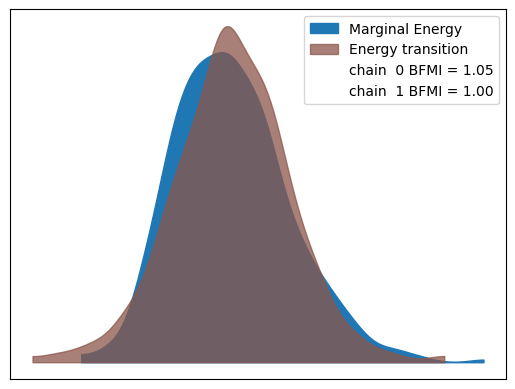

In [ ]:
az.plot_energy(idata);

In [ ]:
var_names_list = [name for name in dfm_mod.param_names if name not in {"x0", "P0"}]

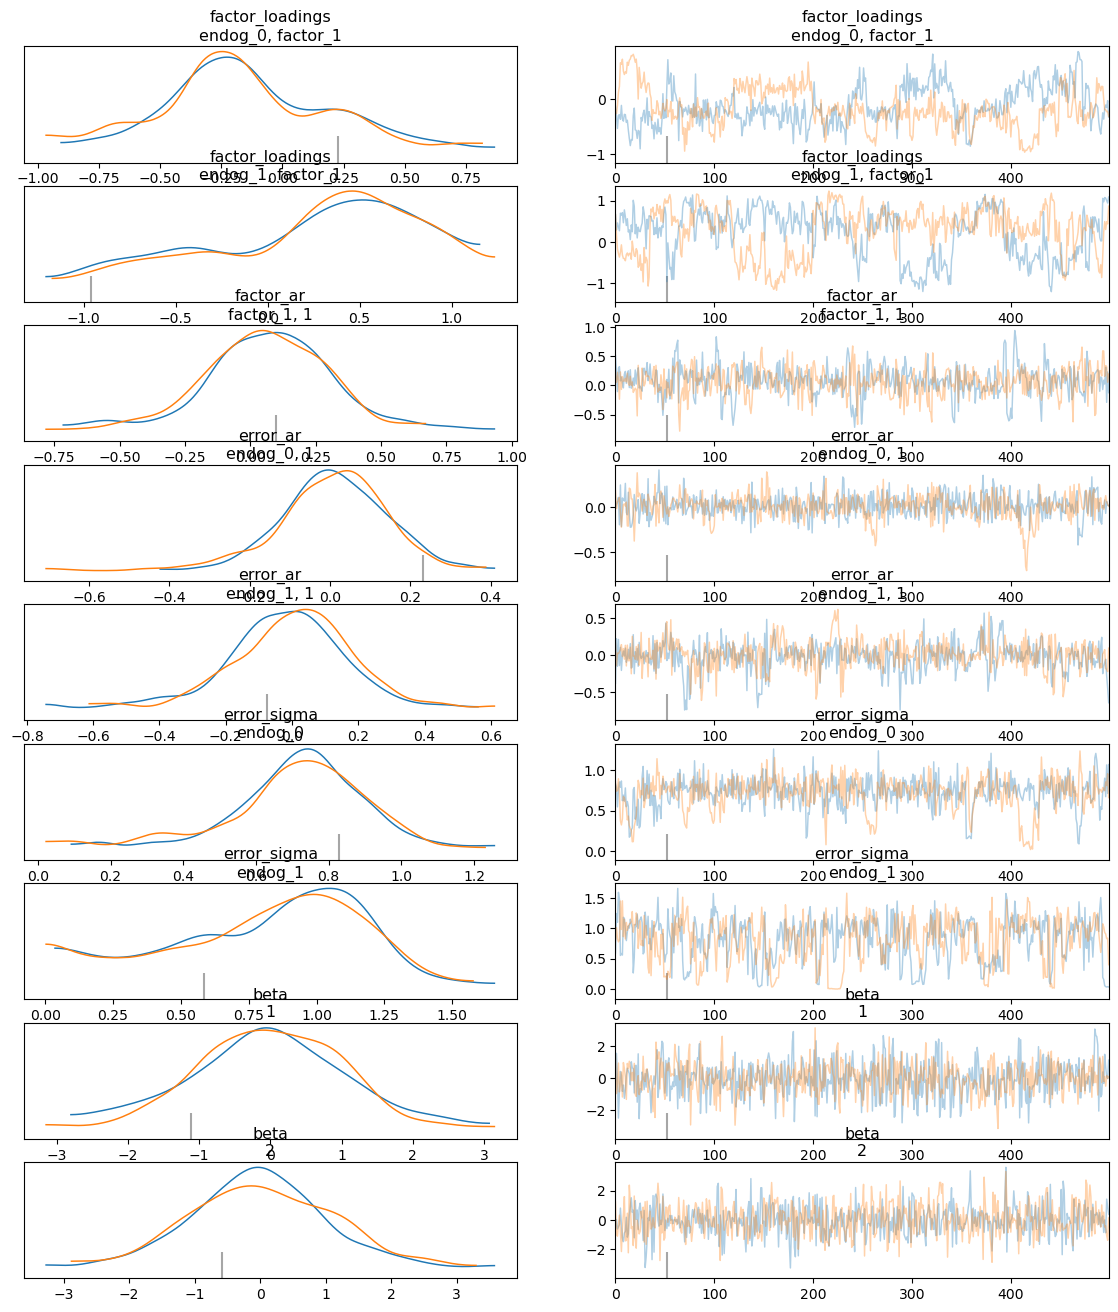

In [ ]:
az.plot_trace(
    idata,
    var_names=var_names_list,
    figsize=(14, 16),
    compact=False
);

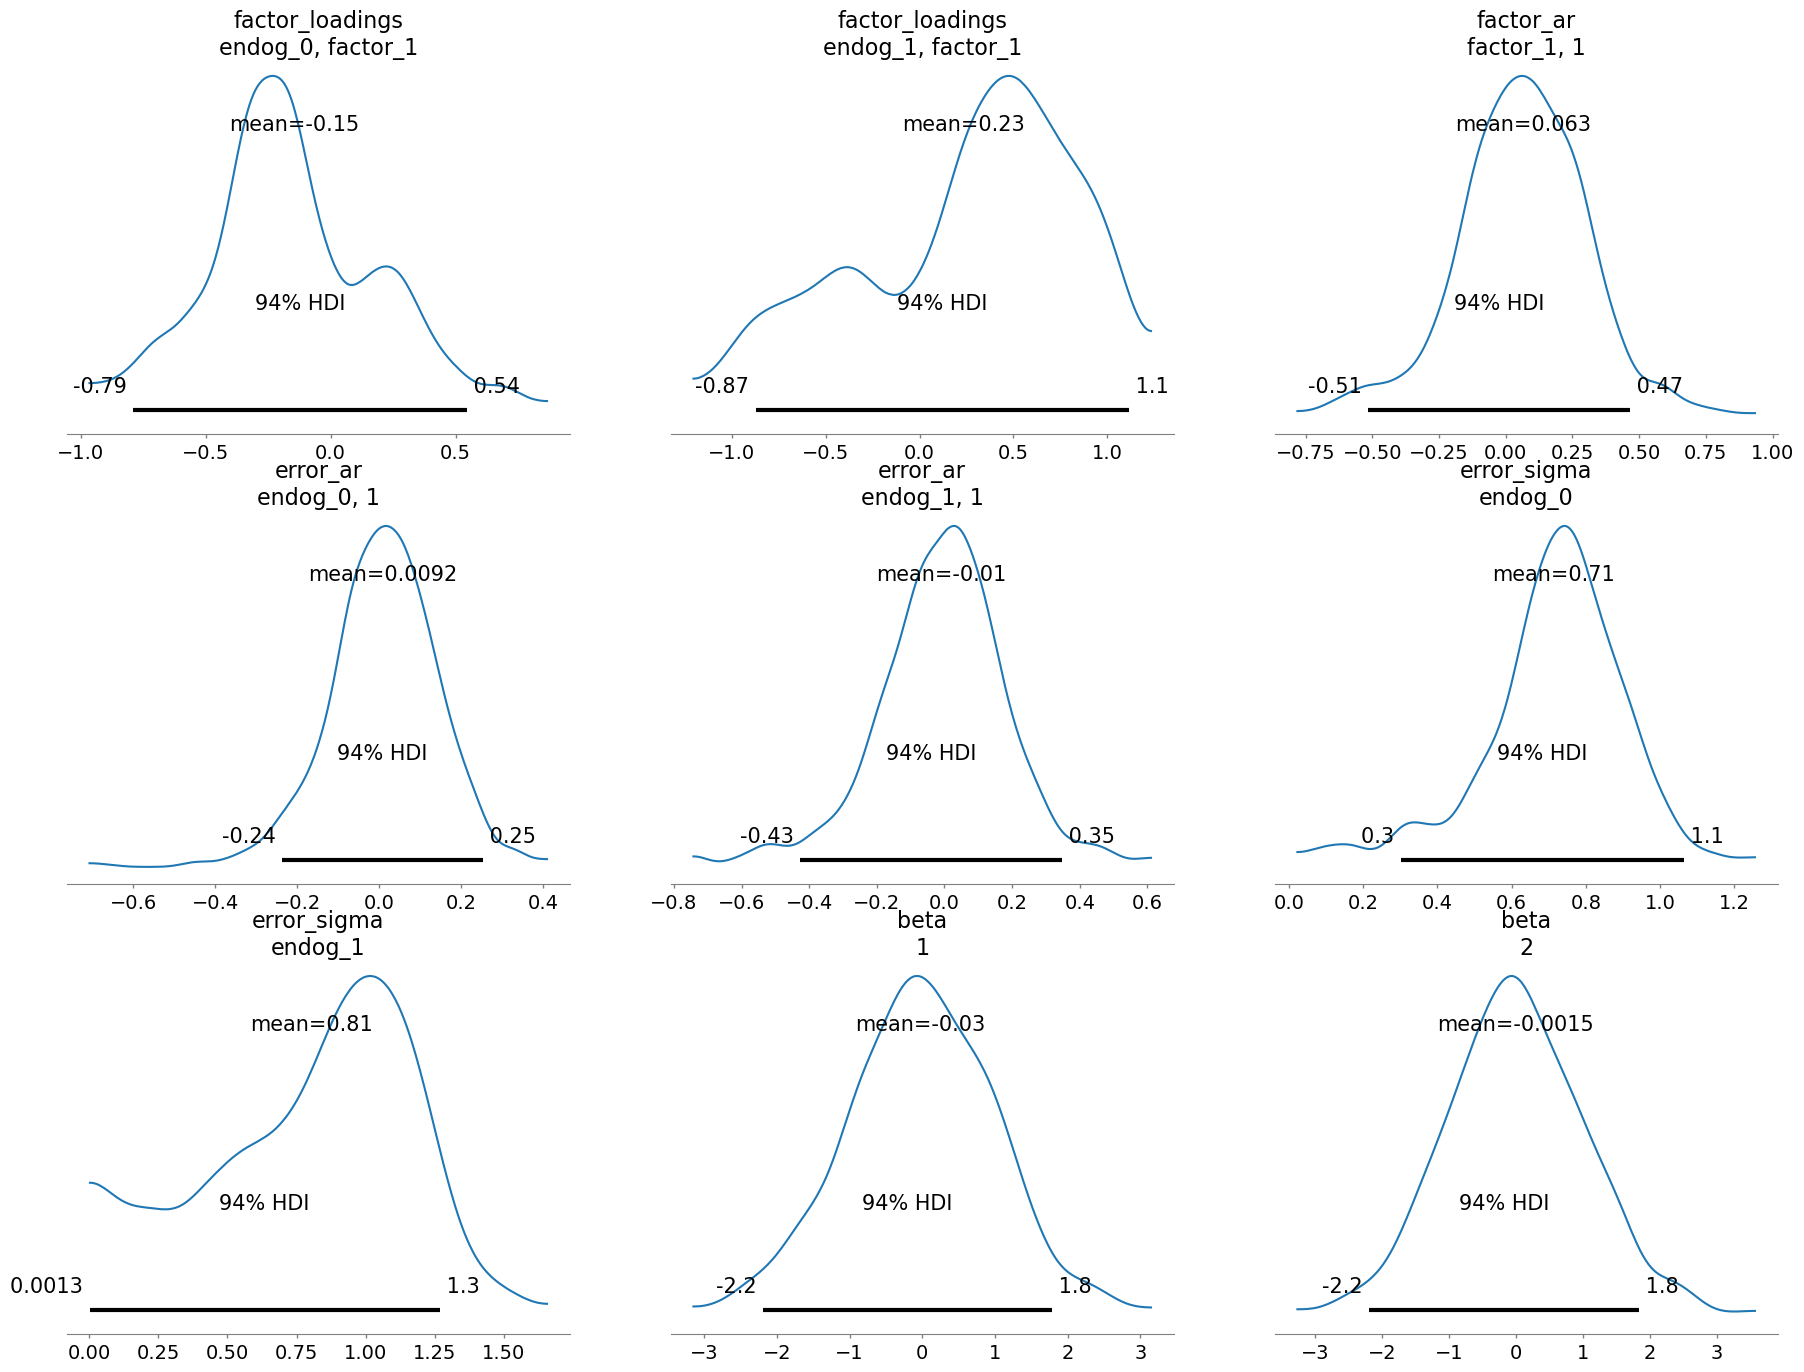

In [ ]:
az.plot_posterior(
    idata,
    var_names=var_names_list  
);